# Residential Energy System Optimization under Solar Generation , Uncertain load Behavior , and Sensitivity Analysis using Python 

## Project Overview

This project analyzes residential energy consumption and evaluates the impact of solar energy on reducing grid dependency. It also investigates the sensitivity of the system to different solar generation levels.


## Data Loading

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("building_energy_data_extended.csv")
df.head()

,Timestamp,Building_ID,Energy_Usage (kWh),Temperature (°C),Humidity (%),Building_Type,Occupancy_Level
0,2025-01-01 00:00:00,B001,121.30,-7.20,79.36,Industrial,Low
1,2025-01-01 01:00:00,B001,230.76,12.62,80.37,Industrial,High
2,2025-01-01 02:00:00,B001,187.21,-1.33,37.74,Industrial,High
3,2025-01-01 03:00:00,B001,262.23,0.24,39.97,Industrial,High
4,2025-01-01 04:00:00,B001,472.97,5.44,89.29,Industrial,Medium


## Initial Data Exploration


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           7200 non-null   str    
 1   Building_ID         7200 non-null   str    
 2   Energy_Usage (kWh)  7200 non-null   float64
 3   Temperature (°C)    7200 non-null   float64
 4   Humidity (%)        7200 non-null   float64
 5   Building_Type       7200 non-null   str    
 6   Occupancy_Level     7200 non-null   str    
dtypes: float64(3), str(4)
memory usage: 393.9 KB


In [ ]:
df.describe()

,Energy_Usage (kWh),Temperature (°C),Humidity (%)
count,7200.000000,7200.000000,7200.000000
mean,277.869099,12.450781,59.826208
std,129.693860,13.033681,17.275891
min,50.050000,-9.990000,30.000000
25%,165.965000,1.017500,44.957500
50%,279.410000,12.550000,59.670000
75%,387.527500,23.772500,74.860000
max,499.920000,35.000000,89.990000


## Initial Raelationship Between Temperature and Energy Usage 

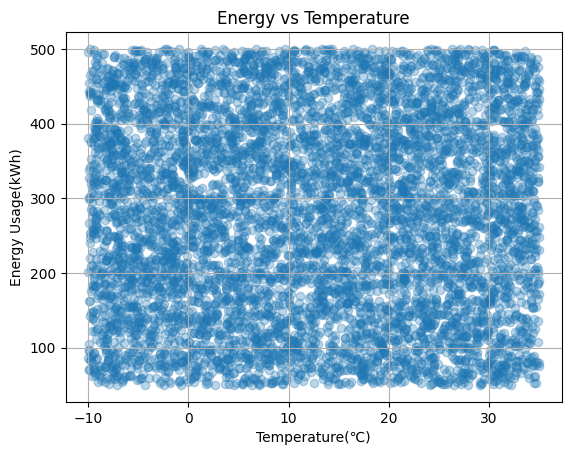

In [ ]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(8,5))
plt.scatter(df["Temperature (°C)"],df["Energy_Usage (kWh)"],alpha=0.3)

plt.xlabel("Temperature(℃)")
plt.ylabel("Energy Usage(kWh)")
plt.title("Energy vs Temperature")
plt.grid(True)
plt.show()

## Building Type Distribution 


In [ ]:
df["Building_Type"].value_counts()

Building_Type
Industrial     2160
Commercial     1800
Educational    1800
Residential    1440
Name: count, dtype: int64

## Filtering Residential Buildings

In [ ]:
df_res=df[df["Building_Type"]== "Residential"]
df_res.head()

,Timestamp,Building_ID,Energy_Usage (kWh),Temperature (°C),Humidity (%),Building_Type,Occupancy_Level
360,2025-01-01 00:00:00,B002,405.73,10.43,48.10,Residential,High
361,2025-01-01 01:00:00,B002,327.31,11.73,53.42,Residential,High
362,2025-01-01 02:00:00,B002,102.88,1.34,85.25,Residential,Low
363,2025-01-01 03:00:00,B002,250.86,14.78,86.67,Residential,High
364,2025-01-01 04:00:00,B002,284.06,11.36,45.50,Residential,Medium


## Residential Energy Consumption Analysis


In [ ]:
df_res["Energy_Usage (kWh)"].describe()


count    1440.000000
mean      285.549431
std       130.724656
min        50.320000
25%       167.640000
50%       290.065000
75%       400.055000
max       499.520000
Name: Energy_Usage (kWh), dtype: float64

## Time and Solar Modeling


In [ ]:
df_res["Timestamp"]=pd.to_datetime(df_res["Timestamp"])
df_res["Hour"]=df_res["Timestamp"].dt.hour

df_res[["Timestamp","Hour"]].head()
df_res["Solar_Generation"]=300 * np.maximum(
    0,
    np.sin((df_res["Hour"] - 6) / 12 * np.pi)
)

## Grid Energy Caluclation


In [ ]:
df_res["Grid_Usage"]=df_res["Energy_Usage (kWh)"] - df_res["Solar_Generation"]
df_res[["Energy_Usage (kWh)","Solar_Generation","Grid_Usage"]].head()

,Energy_Usage (kWh),Solar_Generation,Grid_Usage
360,405.73,0.000000,405.730000
361,327.31,1.964846,325.345154
362,102.88,3.929607,98.950393
363,250.86,5.894200,244.965800
364,284.06,7.858541,276.201459


## Hourly Energy Analysis


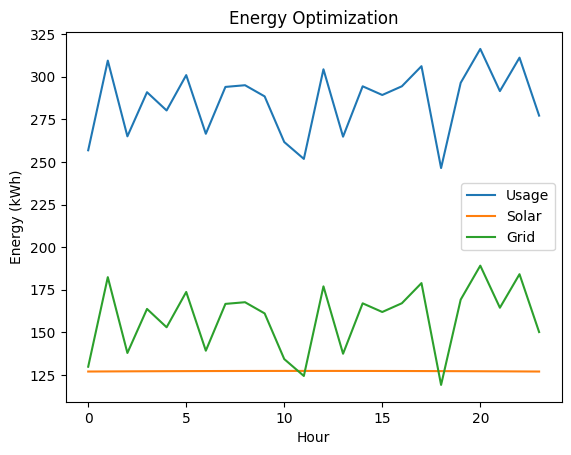

In [ ]:
df_hourly=df_res.groupby("Hour").mean(numeric_only=True)

import matplotlib.pyplot as plt

plt.Figure(figsize=(10,5))

plt.plot(df_hourly.index,df_hourly["Energy_Usage (kWh)"],label="Usage")
plt.plot(df_hourly.index,df_hourly["Solar_Generation"],label="Solar")
plt.plot(df_hourly.index,df_hourly["Grid_Usage"],label="Grid")

plt.legend()
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Energy Optimization")

plt.show()

## Key Performmace Results 


In [ ]:
solar_ratio=df_res["Solar_Generation"].sum() / df_res["Energy_Usage (kWh)"].sum()
print("Solar Contribution Ratio:", solar_ratio)


Solar Contribution Ratio: 0.44558093918625014


In [ ]:
grid_saving=df_res["].sum() - df_res["Grid_Usage"].sum()

print("Energy Saved from Grid:",grid_saving)

Energy Saved from Grid: 183218.9521695025


## Sensitivity Analysis 

 This section shows
  how different solar generation levels impact energy savings.

In [ ]:
solar_levels=[0.5 , 0.75 , 1 , 1.25 , 1.5]
results=[]

for level in solar_levels:
    solar_adjusted=df_res["Solar_Generation"]*level
    grid_new=df_res["Energy_Usage (kWh)"] - solar_adjusted

    grid_new=grid_new.clip(lower=0)
    saving=df_res["Energy_Usage (kWh)"].sum() - grid_new.sum()
    results.append((level,saving))

print(results)
                    

[(0.5, np.float64(88227.82427210442)), (0.75, np.float64(125030.49096186028)), (1, np.float64(156385.0774288008)), (1.25, np.float64(181903.65664818813)), (1.5, np.float64(200929.57912992698))]


In [ ]:
df_sensitivitiy=pd.DataFrame(results,columns=["solar_levels","Energy_Saving"])
df_sensitivitiy

,solar_levels,Energy_Saving
0,0.50,88227.824272
1,0.75,125030.490962
2,1.00,156385.077429
3,1.25,181903.656648
4,1.50,200929.579130


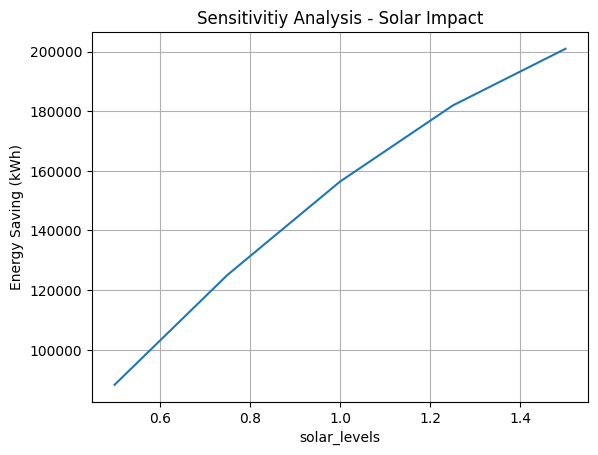

In [ ]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(8,5))
plt.plot(df_sensitivitiy["solar_levels"] , df_sensitivitiy["Energy_Saving"])

plt.xlabel("solar_levels")
plt.ylabel("Energy Saving (kWh)")
plt.title("Sensitivitiy Analysis - Solar Impact")

plt.grid()
plt.show()

## Conclusion

The results show that solar energy significantly reduces dependence on the electrical grid in residential systems. The solar contribution ratio reached approximately 44.6%, indicating that nearly half of the residential energy demand can be covered by solar generation under the modeled conditions.

The estimated energy saved from the grid was about 183,219 kWh, showing that solar integration can effectively reduce grid dependency. In addition, the sensitivity analysis demonstrated that increasing solar generation leads to greater energy savings, confirming that the system performance is strongly influenced by solar availability.

From an engineering perspective, increasing solar generation may represent adding more PV panels, improving panel efficiency, or enhancing the overall solar system performance.
